In [223]:
import pandas as pd

prediction_year=2025
prediction = pd.read_parquet(f'../data/raw/{prediction_year}_prediction.parquet')
ps = pd.read_parquet('../data/raw/processed_pitch_stats.parquet')
# Read downloaded steamer and zips stats
steamer = pd.read_csv(f'../data/raw/steamer-{prediction_year}.csv')
zips = pd.read_csv(f'../data/raw/zips-{prediction_year}.csv')
# Get actual values for predition year, if available
actual = ps[ps['Season'] == prediction_year]

In [224]:
# Merge steamer and zips data. PlayerId == IDfg
# Drop entries with missing PlayerId or ERA; or with minor league id
steamer = steamer.dropna(subset=['PlayerId', 'ERA'])
zips = zips.dropna(subset=['PlayerId', 'ERA'])
steamer = steamer[steamer['PlayerId'].astype(str).str.isnumeric()]
zips = zips[zips['PlayerId'].astype(str).str.isnumeric()]

# Cast the PlayerId to int so merge nicely
steamer['PlayerId'] = steamer['PlayerId'].astype(int)
zips['PlayerId'] = zips['PlayerId'].astype(int)

comparison = prediction.merge(
    zips,
    left_on='IDfg',
    right_on='PlayerId',
    suffixes=('', '_zips')
)
comparison = comparison.merge(
    steamer,
    left_on='IDfg',
    right_on='PlayerId',
    suffixes=('', '_steamer')
)


In [225]:
# Merge in actual values
comparison = comparison.merge(
    actual[['IDfg', 'ERA']],
    on='IDfg',
    suffixes=('', '_actual')
)

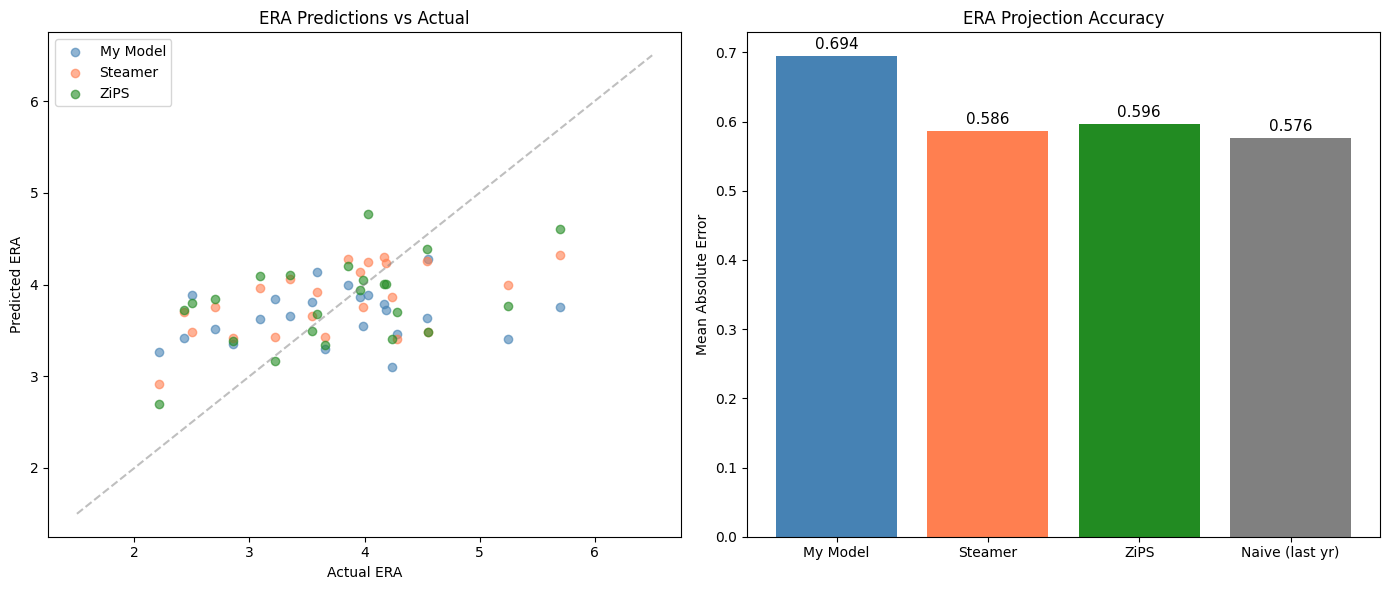

In [226]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Scatter: predicted vs actual ---
ax = axes[0]
ax.scatter(comparison['ERA_actual'], comparison['ERA_predicted'],
           alpha=0.6, label='My Model', color='steelblue')
ax.scatter(comparison['ERA_actual'], comparison['ERA_steamer'],
           alpha=0.6, label='Steamer', color='coral')
ax.scatter(comparison['ERA_actual'], comparison['ERA_zips'],
           alpha=0.6, label='ZiPS', color='forestgreen')

# diagonal "perfect prediction" line
lims = [1.5, 6.5]
ax.plot(lims, lims, '--', color='gray', alpha=0.5)
ax.set_xlabel('Actual ERA')
ax.set_ylabel('Predicted ERA')
ax.set_title('ERA Predictions vs Actual')
ax.legend()

# --- Bar chart: MAE comparison ---
ax = axes[1]
from sklearn.metrics import mean_absolute_error

models = ['My Model', 'Steamer', 'ZiPS', 'Naive (last yr)']
maes = [
    mean_absolute_error(comparison['ERA_actual'], comparison['ERA_predicted']),
    mean_absolute_error(comparison['ERA_actual'], comparison['ERA_steamer']),
    mean_absolute_error(comparison['ERA_actual'], comparison['ERA_zips']),
    mean_absolute_error(comparison['ERA_actual'], comparison['ERA']),  # last year's ERA as naive baseline
]
colors = ['steelblue', 'coral', 'forestgreen', 'gray']
ax.bar(models, maes, color=colors)
ax.set_ylabel('Mean Absolute Error')
ax.set_title('ERA Projection Accuracy')

# label the bars with values
for i, v in enumerate(maes):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(f'era_comparison_{prediction_year}.png', dpi=150, bbox_inches='tight')
plt.show()